# CSE422 Lab Project: Credit Risk Prediction

## 1. Introduction
**Target Feature:** `loan_status` (Discrete: 0 = No Default, 1 = Default)

**Aim & Problem Description:**
The aim of this project is to predict credit risk by identifying whether a prospective borrower is likely to default on a personal loan. The problem focuses on using historical financial, demographic, and employment data to classify loan applications accurately.




##Setup

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/14.csv')

#Dataset Description

In [ ]:
#Dimensions
print("Dataset Shape:", df.shape)
print("-" * 40)

#Basic information about data types and non-null counts
df.info()
print("-" * 40)

#Check for any missing/null values
print("Missing Values:\n", df.isnull().sum())
print("-" * 40)

#First 5 rows
df.head()

Dataset Shape: (45000, 14)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score             

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
#Checking unique values
df.nunique()

,0
person_age,60
person_gender,2
person_education,5
person_income,33989
person_emp_exp,63
person_home_ownership,4
loan_amnt,4483
loan_intent,6
loan_int_rate,1302
loan_percent_income,64


loan_status
0    77.777778
1    22.222222
Name: proportion, dtype: float64


/tmp/ipykernel_1345/2865670441.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='loan_status', palette='coolwarm')


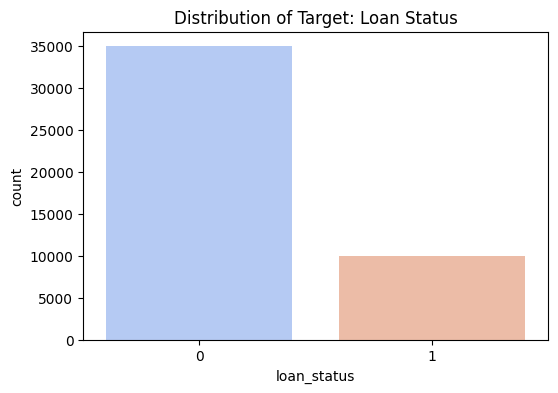

In [ ]:
#Check target distribution
print(df['loan_status'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='loan_status', palette='coolwarm')
plt.title('Distribution of Target: Loan Status')
plt.show()

The data is imbalanced.

## Selecting categorical features


In [ ]:
categorical_data = df.select_dtypes(include=['object'])
categorical_features = categorical_data.columns.tolist()
print("Categorical features:", categorical_features)


Categorical features: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


# Selecting numerical features


In [ ]:
numerical_data = df.select_dtypes(include=['number'])
numerical_features = numerical_data.columns.tolist()
numerical_features.remove('loan_status') # Remove target from feature list
print("Numerical features:", numerical_features)

Numerical features: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


In [ ]:
# Summary statistics for numerical features
print("--- Numerical Summary ---")
display(df.describe().round(2))

# Summary statistics for categorical features
print("\n--- Categorical Summary ---")
display(df.describe(include=['object']))

--- Numerical Summary ---


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00
mean,27.76,80319.05,5.41,9583.16,11.01,0.14,5.87,632.61,0.22
std,6.05,80422.50,6.06,6314.89,2.98,0.09,3.88,50.44,0.42
min,20.00,8000.00,0.00,500.00,5.42,0.00,2.00,390.00,0.00
25%,24.00,47204.00,1.00,5000.00,8.59,0.07,3.00,601.00,0.00
50%,26.00,67048.00,4.00,8000.00,11.01,0.12,4.00,640.00,0.00
75%,30.00,95789.25,8.00,12237.25,12.99,0.19,8.00,670.00,0.00
max,144.00,7200766.00,125.00,35000.00,20.00,0.66,30.00,850.00,1.00



--- Categorical Summary ---


,person_gender,person_education,person_home_ownership,loan_intent,previous_loan_defaults_on_file
count,45000,45000,45000,45000,45000
unique,2,5,4,6,2
top,male,Bachelor,RENT,EDUCATION,Yes
freq,24841,13399,23443,9153,22858


In [ ]:
#Checking impossible values
invalid_age = df[df['person_age'] > 100]
invalid_exp = df[df['person_emp_exp'] > 60]

print(f"Number of records with age > 100: {len(invalid_age)}")
print(f"Number of records with employment experience > 60: {len(invalid_exp)}")

display(invalid_age[['person_age', 'person_emp_exp', 'person_income', 'loan_amnt', 'loan_status']].head())
display(invalid_exp[['person_age', 'person_emp_exp', 'person_income', 'loan_amnt', 'loan_status']].head())

Number of records with age > 100: 7
Number of records with employment experience > 60: 10


,person_age,person_emp_exp,person_income,loan_amnt,loan_status
81,144.0,125,300616.0,4800.0,0
183,144.0,121,241424.0,6000.0,0
575,123.0,101,97140.0,20400.0,0
747,123.0,100,94723.0,20000.0,0
32297,144.0,124,7200766.0,5000.0,0


,person_age,person_emp_exp,person_income,loan_amnt,loan_status
81,144.0,125,300616.0,4800.0,0
183,144.0,121,241424.0,6000.0,0
575,123.0,101,97140.0,20400.0,0
747,123.0,100,94723.0,20000.0,0
32297,144.0,124,7200766.0,5000.0,0


In [ ]:
numerical_data.skew()

,0
person_age,2.548154
person_income,34.137583
person_emp_exp,2.594917
loan_amnt,1.179731
loan_int_rate,0.213784
loan_percent_income,1.034512
cb_person_cred_hist_length,1.631720
credit_score,-0.610261
loan_status,1.336351


Here `person_income` highly right-skewed

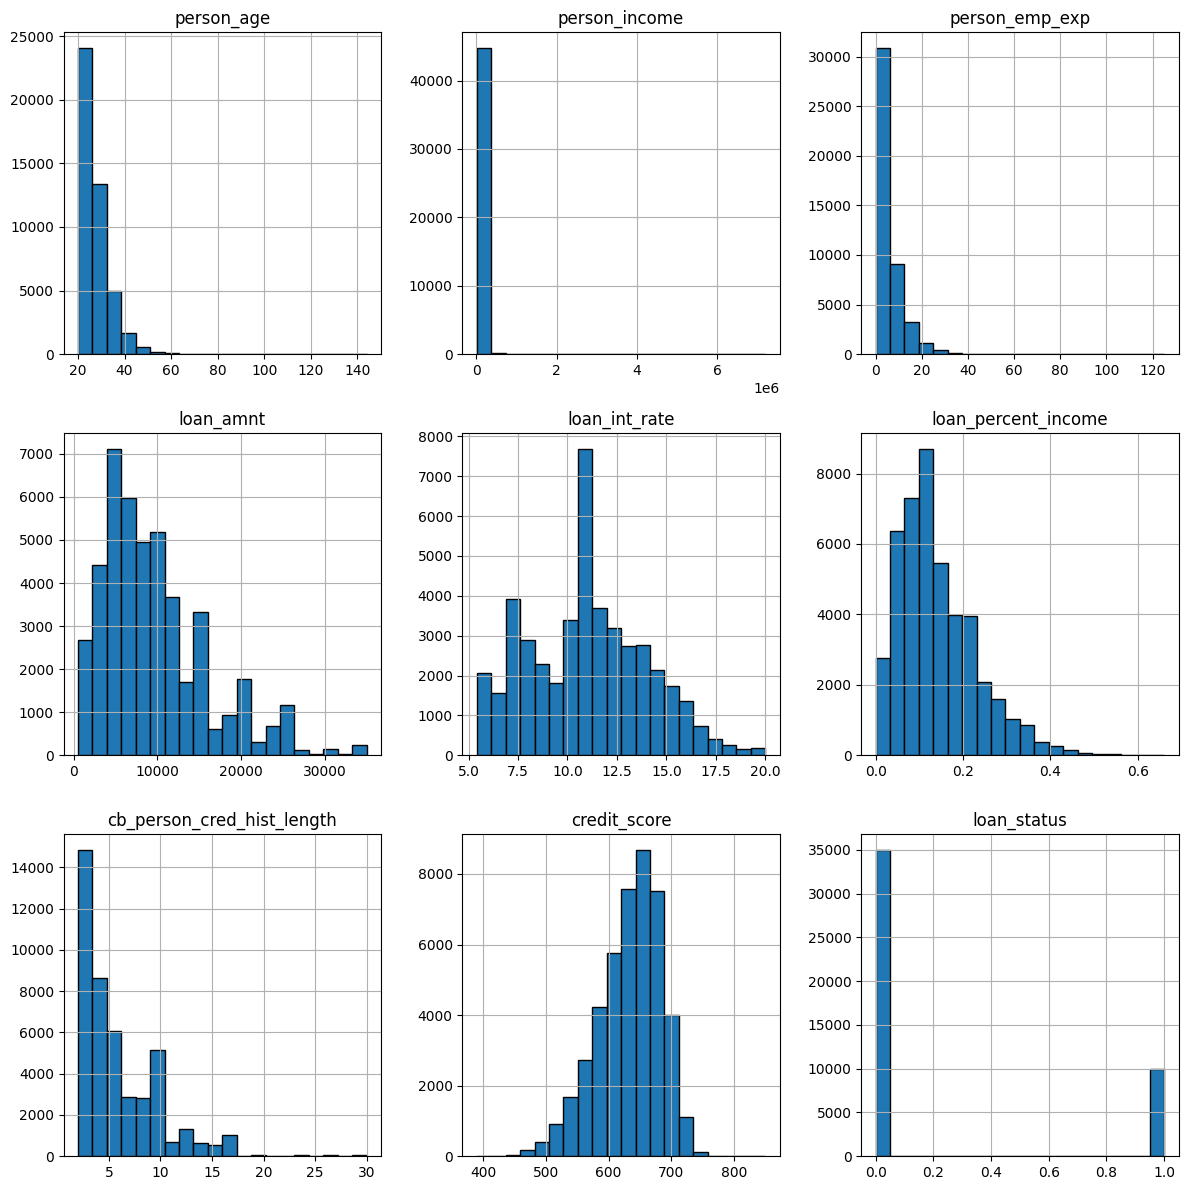

In [ ]:
numerical_data = df.select_dtypes(include=['int64', 'float64'])

numerical_data.hist(figsize=(12, 12), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

Here `person_income` is extremely right skewed, justifying the high skewness value.
`person_age`, `person_emp_exp`, and `cb_person_cred_hist_length` are also highly right skewed. `loan_amnt` and `loan_percent_income`are slightly right skewed. The rest are nearly symmetrical.

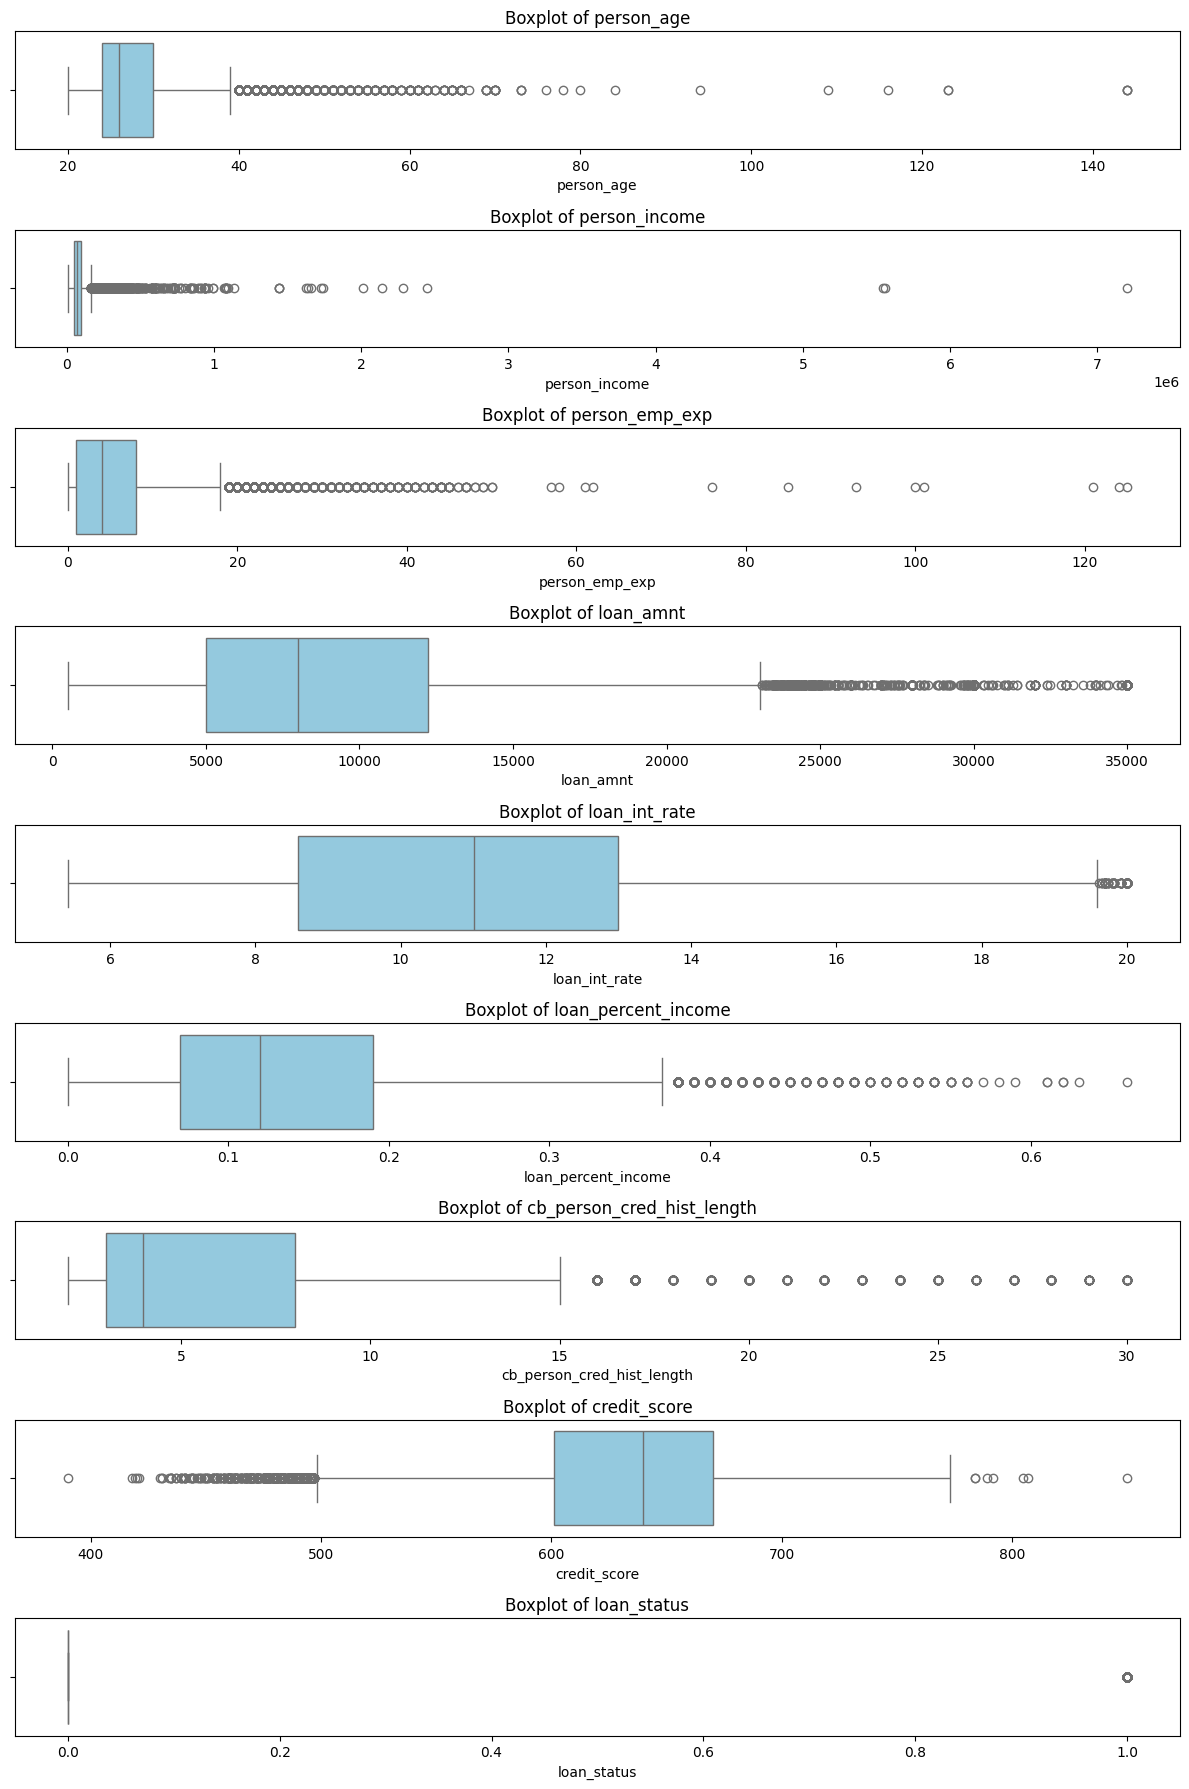

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 18))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)

plt.tight_layout()
plt.show()

`person_age`, `person_income` and `person_emp_exp` has a lot of outliers in the right side. `loan_amnt`, `loan_int_rate`, and `loan_percent_income` have moderate amount of outliers in the right. `cb_person_cred_hist_length` has a few outliers in right. `credit_score` has outliers in both side.

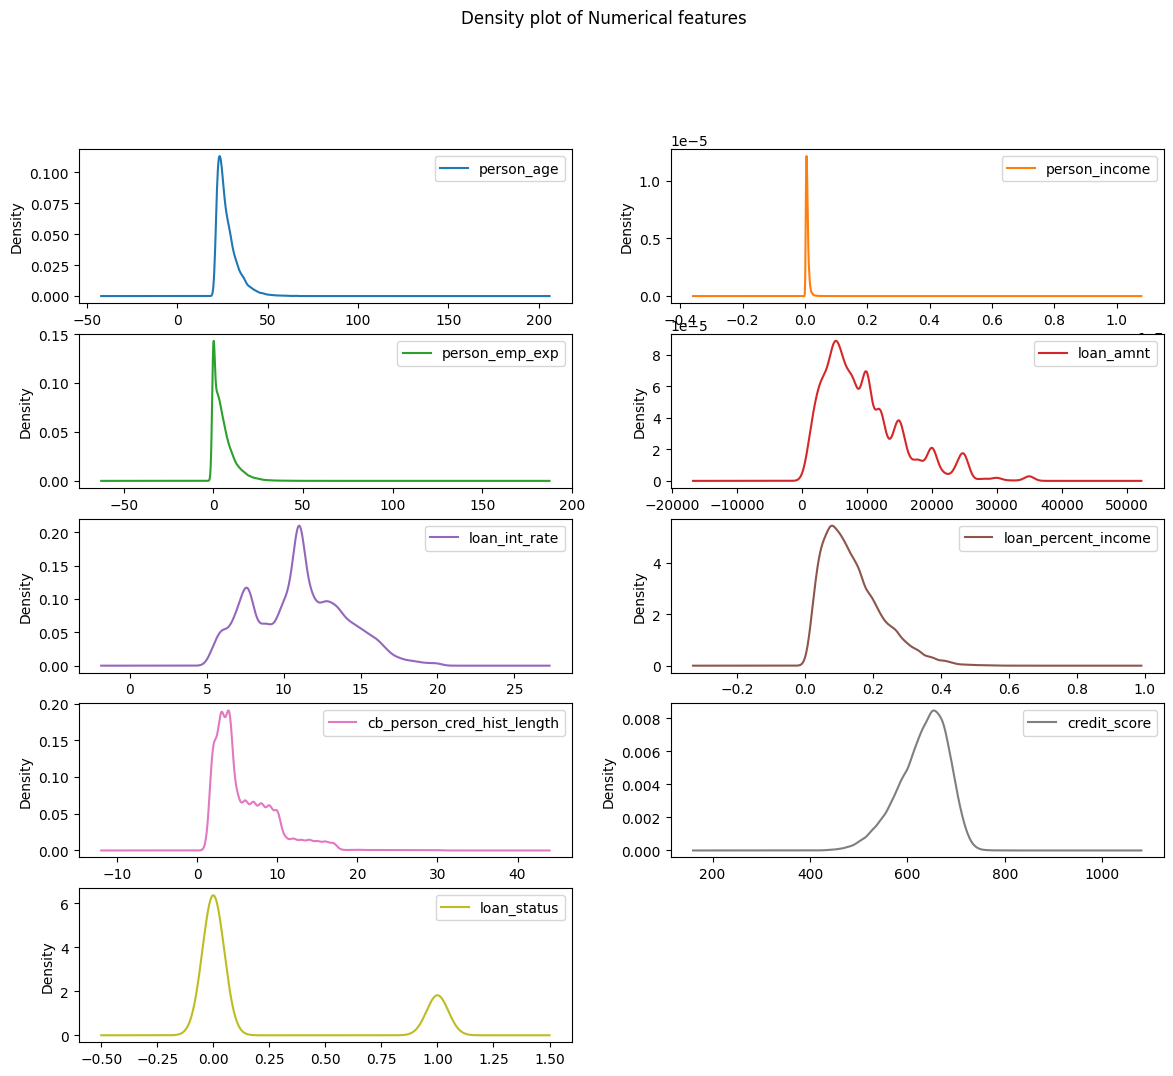

In [ ]:
numerical_data.plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

#Correlation Heatmap

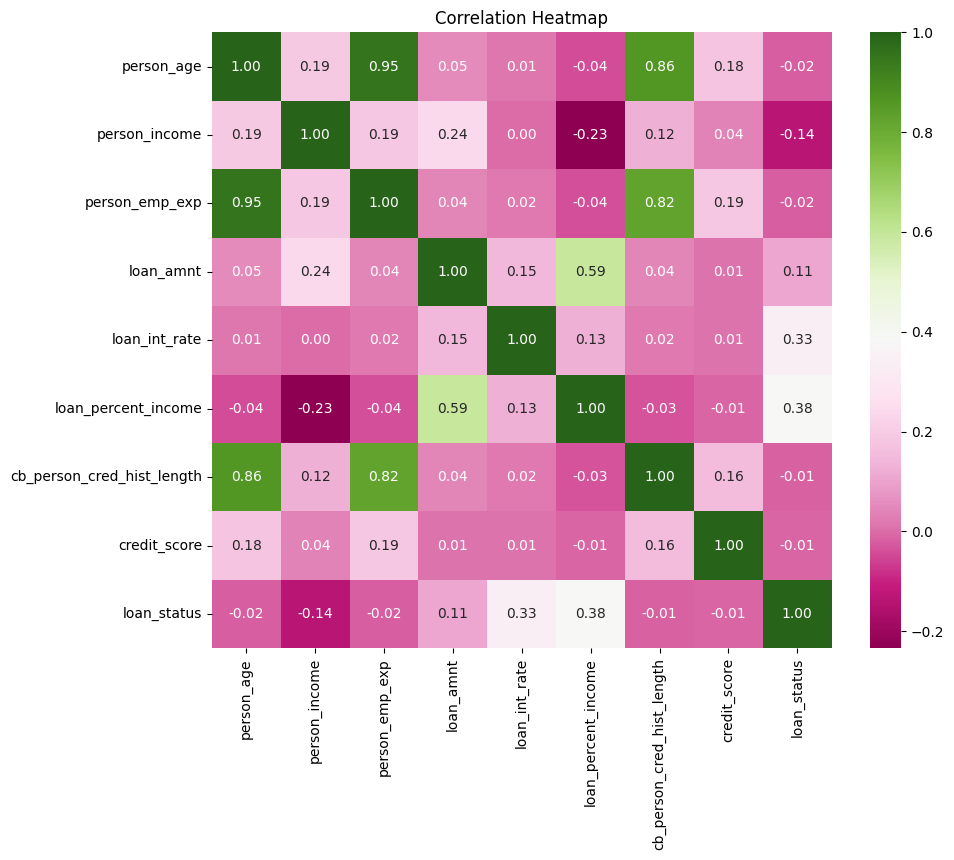

In [ ]:
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_features + ['loan_status']].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="PiYG")
plt.title("Correlation Heatmap")
plt.show()

1. `loan_percent_income` and `loan_int_rate` have the strongest positive correlation with `loan_status`
2. Multicollinearity between `person_age` and `person_emp_exp` and `cb_person_cred_hist_length`.

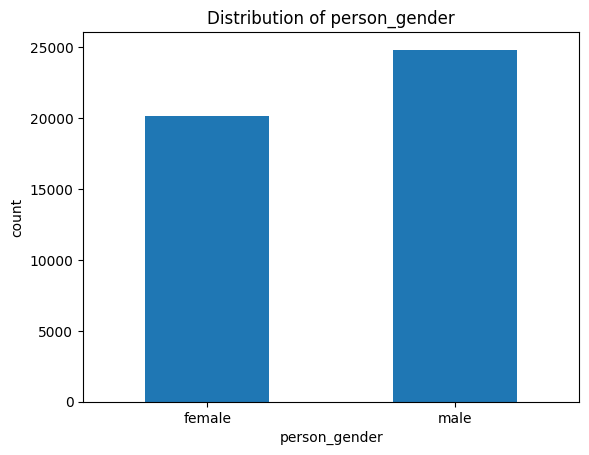

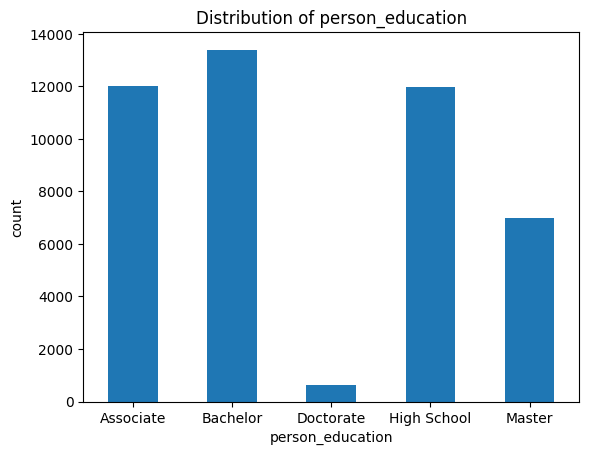

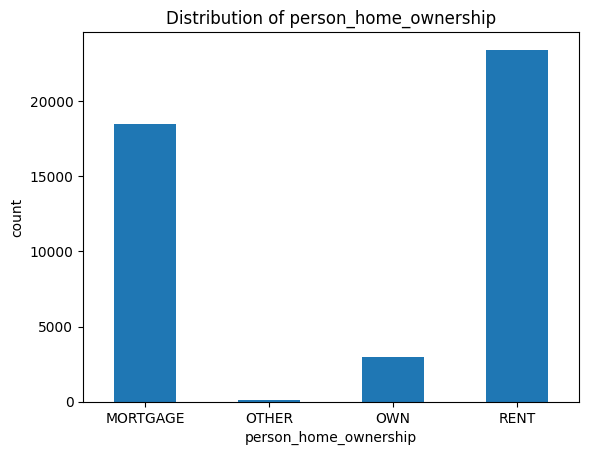

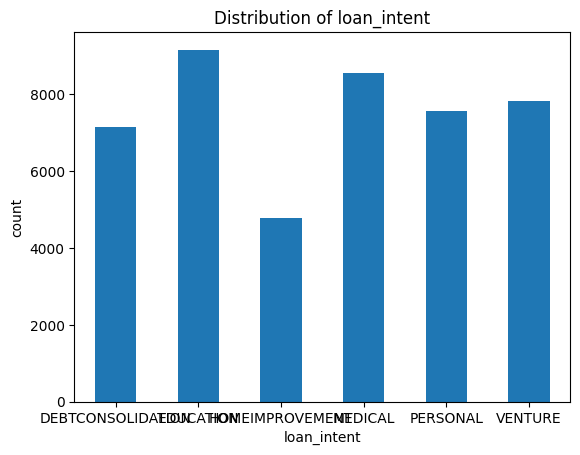

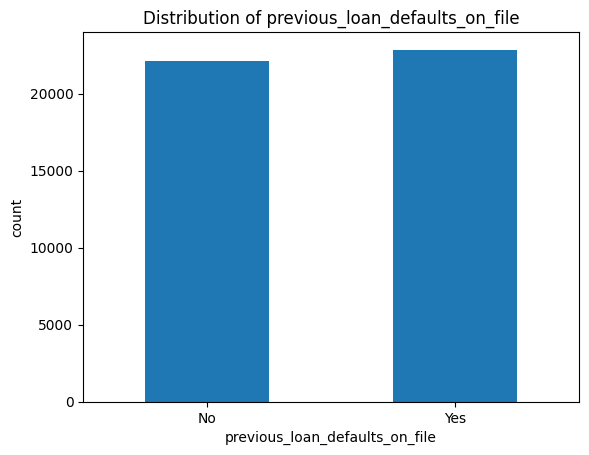

In [ ]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

##Pre-processing

In [ ]:
#Checking and dropping duplicate rows
initial_rows = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {initial_rows - len(df)} duplicate rows.")

#Handling Outliers and Logical Consistency
df = df[
    (df['person_age'] <= 100) &
    (df['person_emp_exp'] <= 60) &
    (df['person_emp_exp'] <= (df['person_age'] - 16))
].reset_index(drop=True)
print(f"Total records after outlier/logic cleanup: {len(df)}")

#Handling extreme skewness using log transformation
df['person_income'] = np.log1p(df['person_income'])

#Separating Features (X) and Target (y)
X = df.drop('loan_status', axis=1)
y = df['loan_status']

#Encoding Categorical Values (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

#Feature Selection
X_selected = X_encoded.drop(['cb_person_cred_hist_length', 'person_emp_exp'], axis=1)
print(f"Features remaining: {X_selected.shape[1]}")
print("Final Feature Set:")
print(X_selected.columns.tolist())

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train_scaled.shape[0]} samples")
print(f"Testing set: {X_test_scaled.shape[0]} samples")

Dropped 0 duplicate rows.
Total records after outlier/logic cleanup: 44990
Features remaining: 20
Final Feature Set:
['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'credit_score', 'person_gender_male', 'person_education_Bachelor', 'person_education_Doctorate', 'person_education_High School', 'person_education_Master', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'previous_loan_defaults_on_file_Yes']

Training set: 35992 samples
Testing set: 8998 samples


#Model Training

--- Logistic Regression Performance ---
Accuracy: 0.8540786841520338
Precision: 0.6137793971513746
Recall: 0.9265
F1-Score: 0.7383941024108388

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.83      0.90      6998
           1       0.61      0.93      0.74      2000

    accuracy                           0.85      8998
   macro avg       0.79      0.88      0.82      8998
weighted avg       0.90      0.85      0.86      8998



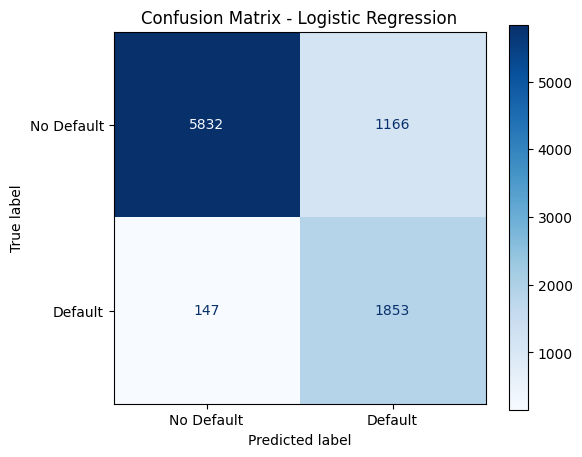

In [ ]:
# Logistic Regression
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("--- Logistic Regression Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-Score:", f1_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(log_reg, X_test_scaled, y_test, display_labels=['No Default', 'Default'], cmap='Blues', ax=ax)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
#KNN
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
param_grid = {'n_neighbors': range(3, 22, 2)}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_scaled, y_train)

best_k = grid_search.best_params_['n_neighbors']
print(f"Best k based on GridSearchCV F1-score: {best_k}")

Best k based on GridSearchCV F1-score: 9


--- KNN Performance ---
Accuracy: 0.9027561680373416
Precision: 0.8314672952268709
Recall: 0.7055
F1-Score: 0.7633216121179335

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      6998
           1       0.83      0.71      0.76      2000

    accuracy                           0.90      8998
   macro avg       0.88      0.83      0.85      8998
weighted avg       0.90      0.90      0.90      8998



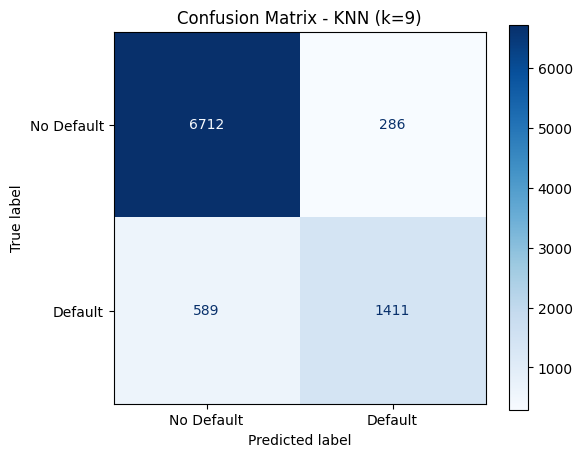

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

print("--- KNN Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-Score:", f1_score(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, display_labels=['No Default', 'Default'], cmap='Blues', ax=ax)
plt.title(f"Confusion Matrix - KNN (k={best_k})")
plt.show()

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8012 - loss: 0.3907 - val_accuracy: 0.8556 - val_loss: 0.2884
Epoch 2/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8542 - loss: 0.2822 - val_accuracy: 0.8608 - val_loss: 0.2781
Epoch 3/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8600 - loss: 0.2668 - val_accuracy: 0.8661 - val_loss: 0.2687
Epoch 4/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8649 - loss: 0.2584 - val_accuracy: 0.8708 - val_loss: 0.2671
Epoch 5/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8669 - loss: 0.2537 - val_accuracy: 0.8731 - val_loss: 0.2585
Epoch 6/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8685 - loss: 0.2496 - val_accuracy: 0.8731 - val_loss: 0.2541
Epoch 7/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8701 - loss: 0.2465 - val_accuracy: 0.8714 - val_loss: 0.2537
Epoch 8/20
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8734 - loss: 0.2433 - val_accuracy: 0.8739 - val_

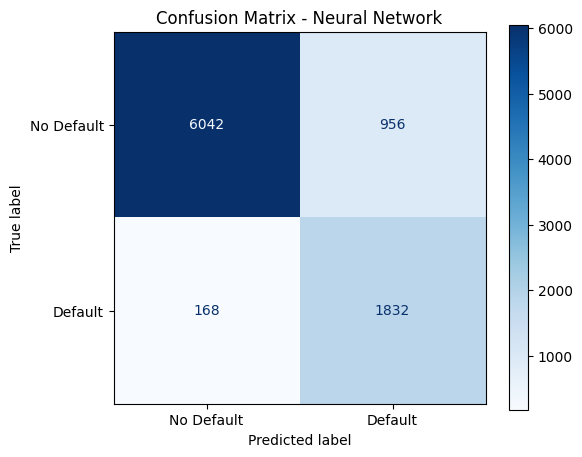

In [ ]:
#Neural Network
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))

nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    class_weight=class_weights_dict,
    verbose=1
)

y_pred_probs = nn_model.predict(X_test_scaled)
y_pred_nn = (y_pred_probs >= 0.5).astype(int)

print("\n--- Neural Network Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print("Precision:", precision_score(y_test, y_pred_nn))
print("Recall:", recall_score(y_test, y_pred_nn))
print("F1-Score:", f1_score(y_test, y_pred_nn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nn, display_labels=['No Default', 'Default'], cmap='Blues', ax=ax)
plt.title("Confusion Matrix - Neural Network")
plt.show()

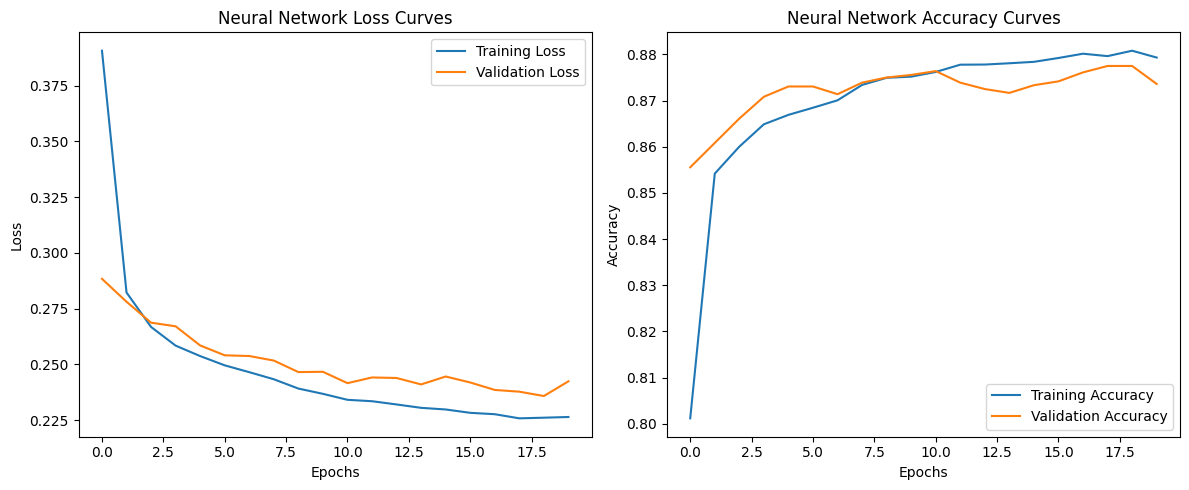

In [ ]:
# Plot of training and validation loss & accuracy curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Neural Network Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

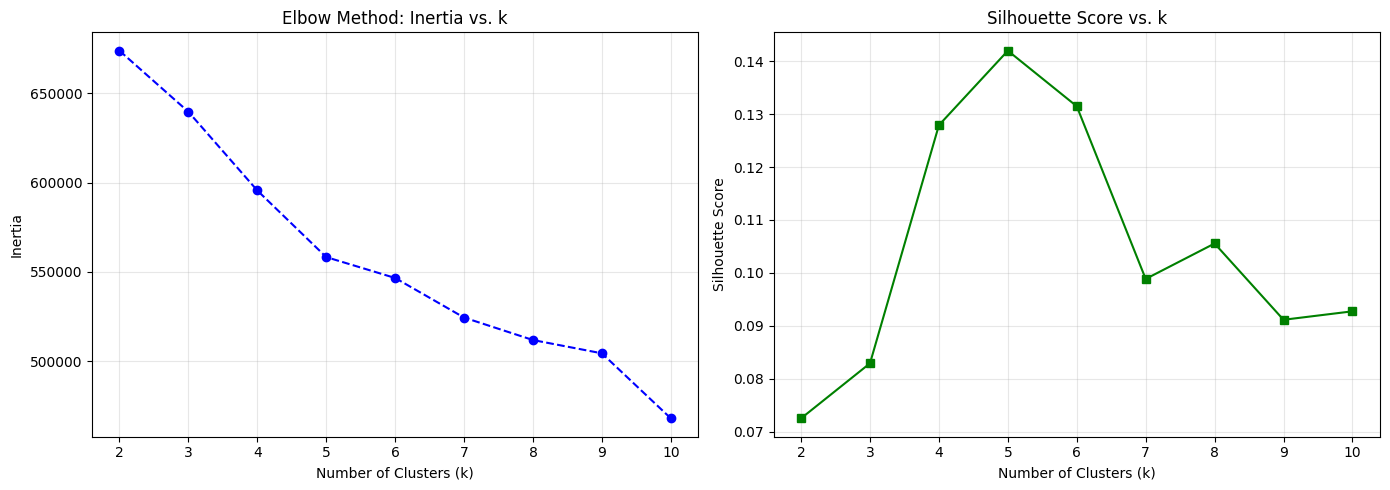

In [ ]:
#K-Means Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(2, 11)
inertia = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_train_scaled)

    inertia.append(kmeans.inertia_)
    sil_score = silhouette_score(X_train_scaled, cluster_labels, sample_size=5000, random_state=42)
    silhouette_scores.append(sil_score)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertia, marker='o', linestyle='--', color='blue')
ax1.set_title('Elbow Method: Inertia vs. k')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(k_range)
ax1.grid(alpha=0.3)

ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='green')
ax2.set_title('Silhouette Score vs. k')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Silhouette Scores peaks at k = 5

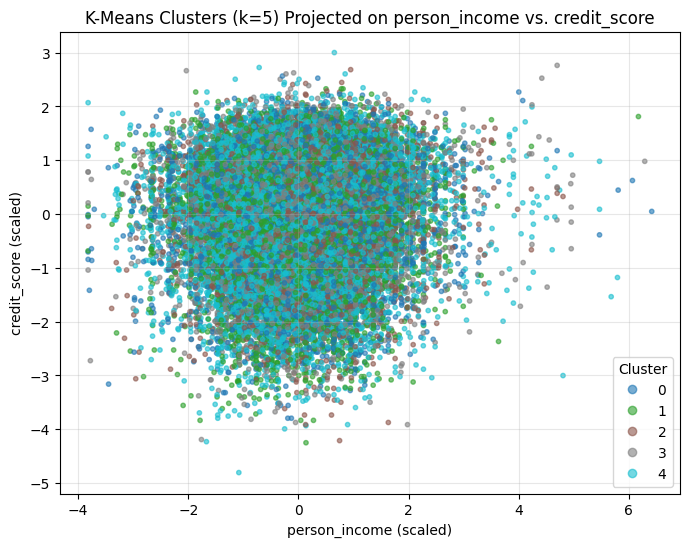

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans_final = KMeans(n_clusters=5, random_state=42, n_init='auto')
cluster_labels = kmeans_final.fit_predict(X_train_scaled)

feat1, feat2 = "person_income", "credit_score"
idx1 = X_train.columns.get_loc(feat1)
idx2 = X_train.columns.get_loc(feat2)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_scaled[:, idx1], X_train_scaled[:, idx2],
                       c=cluster_labels, cmap='tab10', s=10, alpha=0.6)
plt.title(f"K-Means Clusters (k=5) Projected on {feat1} vs. {feat2}")
plt.xlabel(f"{feat1} (scaled)")
plt.ylabel(f"{feat2} (scaled)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.grid(alpha=0.3)
plt.show()

# Comparison

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


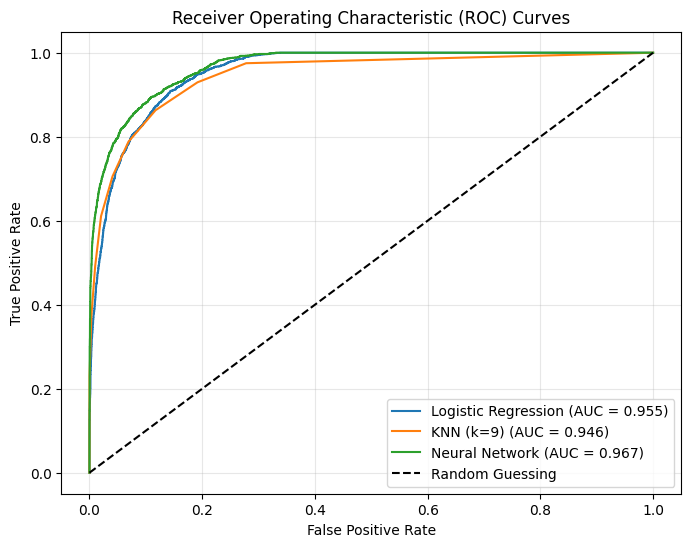


--- Final Model Comparison ---


,Model,Accuracy,Precision,Recall,F1 Score,AUC Score
0,Logistic Regression,0.8541,0.6138,0.9265,0.7384,0.9550
1,KNN (k=9),0.9028,0.8315,0.7055,0.7633,0.9457
2,Neural Network,0.8751,0.6571,0.9160,0.7652,0.9672


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

# Probability predictions
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]
y_prob_nn = nn_model.predict(X_test_scaled).ravel()

# ROC and AUC calculation
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = auc(fpr_knn, tpr_knn)

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (k={best_k}) (AUC = {auc_knn:.3f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

metrics_data = {
    'Model': ['Logistic Regression', f'KNN (k={best_k})', 'Neural Network'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_knn), accuracy_score(y_test, y_pred_nn)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_knn), precision_score(y_test, y_pred_nn)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_knn), recall_score(y_test, y_pred_nn)],
    'F1 Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_knn), f1_score(y_test, y_pred_nn)],
    'AUC Score': [auc_lr, auc_knn, auc_nn]
}

comparison_df = pd.DataFrame(metrics_data)
print("\n--- Final Model Comparison ---")
display(comparison_df.round(4))

Here, the best model would be Neural Network with Highest AUC and F1 score and a good Recall.